In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cd /content/drive/MyDrive/dl_project


In [5]:
!ls /content/drive/MyDrive/dl_project

FSDD_dataset  FSDD_multi_dataset


In [6]:
import os

dataset_path = "/content/drive/MyDrive/dl_project/FSDD_multi_dataset"
files = os.listdir(dataset_path)
print("Total files:", len(files))
print(files)

Total files: 3000
['99_theo_4.wav', '00_george_1.wav', '01_george_1.wav', '00_george_0.wav', '99_theo_2.wav', '00_george_4.wav', '02_george_2.wav', '00_george_2.wav', '01_george_4.wav', '99_theo_3.wav', '99_theo_0.wav', '01_george_2.wav', '00_george_3.wav', '05_george_2.wav', '03_george_2.wav', '03_george_3.wav', '04_george_1.wav', '04_george_0.wav', '05_george_0.wav', '03_george_1.wav', '04_george_2.wav', '03_george_4.wav', '04_george_4.wav', '02_george_4.wav', '03_george_0.wav', '04_george_3.wav', '02_george_3.wav', '05_george_1.wav', '07_george_1.wav', '08_george_0.wav', '05_george_4.wav', '06_george_1.wav', '07_george_4.wav', '08_george_2.wav', '06_george_0.wav', '07_george_0.wav', '08_george_1.wav', '07_george_2.wav', '07_george_3.wav', '06_george_3.wav', '06_george_4.wav', '05_george_3.wav', '08_george_3.wav', '06_george_2.wav', '11_george_1.wav', '10_george_4.wav', '09_george_2.wav', '09_george_0.wav', '09_george_1.wav', '10_george_0.wav', '11_george_0.wav', '10_george_1.wav', '

In [53]:
!pip install librosa

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [54]:
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset

class MFCCDataset(Dataset):
    def __init__(self, files, path):
        self.files = files
        self.path = path

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]

        # label (00–99 → int)
        label = int(file.split("_")[0])

        y, sr = librosa.load(os.path.join(self.path, file), sr=8000)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # 🔥 normalize
        mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

        # 🔥 pad / truncate
        max_len = 32
        if mfcc.shape[1] < max_len:
            pad = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad)))
        else:
            mfcc = mfcc[:, :max_len]

        mfcc = torch.tensor(mfcc, dtype=torch.float32)

        return mfcc, label

In [55]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)

train_dataset = MFCCDataset(train_files, dataset_path)
val_dataset = MFCCDataset(val_files, dataset_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [59]:
print(len(train_dataset),len(val_dataset))

2400 600


In [60]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(32 * 10 * 8, 128)
        self.fc2 = nn.Linear(128, 100)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,40,32)

        x = self.pool(F.relu(self.conv1(x)))  # (B,16,20,16)
        x = self.pool(F.relu(self.conv2(x)))  # (B,32,10,8)

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [61]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 15

for epoch in range(epochs):
    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/15 | Train Acc: 0.012 | Val Acc: 0.012
Epoch 2/15 | Train Acc: 0.026 | Val Acc: 0.037
Epoch 3/15 | Train Acc: 0.072 | Val Acc: 0.143
Epoch 4/15 | Train Acc: 0.142 | Val Acc: 0.225
Epoch 5/15 | Train Acc: 0.234 | Val Acc: 0.345
Epoch 6/15 | Train Acc: 0.344 | Val Acc: 0.437
Epoch 7/15 | Train Acc: 0.435 | Val Acc: 0.480
Epoch 8/15 | Train Acc: 0.510 | Val Acc: 0.595
Epoch 9/15 | Train Acc: 0.598 | Val Acc: 0.665
Epoch 10/15 | Train Acc: 0.628 | Val Acc: 0.663
Epoch 11/15 | Train Acc: 0.667 | Val Acc: 0.703
Epoch 12/15 | Train Acc: 0.713 | Val Acc: 0.745
Epoch 13/15 | Train Acc: 0.749 | Val Acc: 0.750
Epoch 14/15 | Train Acc: 0.763 | Val Acc: 0.737
Epoch 15/15 | Train Acc: 0.775 | Val Acc: 0.768


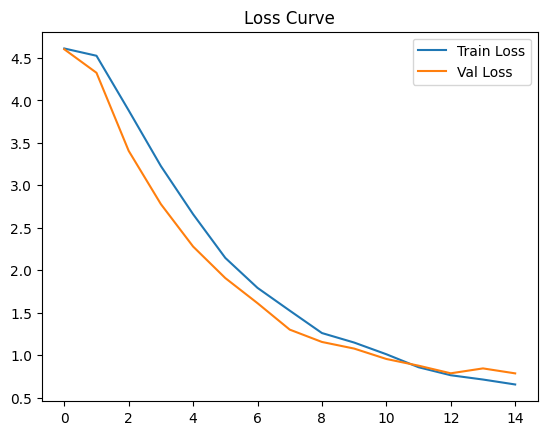

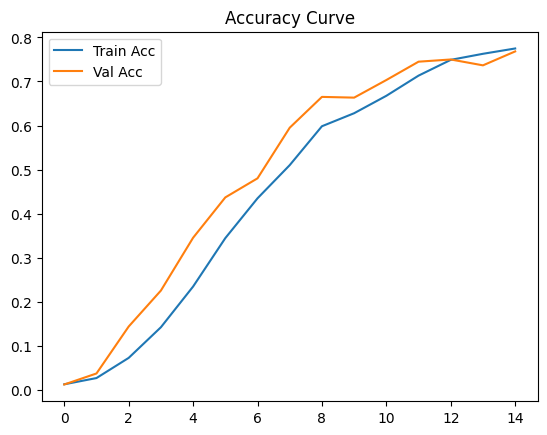

In [62]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [63]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=40,   # MFCC features
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 100)  # 100 classes

    def forward(self, x):
        # x: (B, 40, 32)

        x = x.permute(0, 2, 1)  # (B, 32, 40)

        out, _ = self.lstm(x)

        # take last time step
        out = out[:, -1, :]  # (B, 128)

        out = self.dropout(torch.relu(self.fc1(out)))
        out = self.fc2(out)

        return out

In [66]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = CNNModel().to(device)
model = LSTMModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 15

for epoch in range(epochs):
    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/15 | Train Acc: 0.009 | Val Acc: 0.008
Epoch 2/15 | Train Acc: 0.011 | Val Acc: 0.007
Epoch 3/15 | Train Acc: 0.011 | Val Acc: 0.005
Epoch 4/15 | Train Acc: 0.010 | Val Acc: 0.003
Epoch 5/15 | Train Acc: 0.015 | Val Acc: 0.010
Epoch 6/15 | Train Acc: 0.019 | Val Acc: 0.010
Epoch 7/15 | Train Acc: 0.018 | Val Acc: 0.022
Epoch 8/15 | Train Acc: 0.023 | Val Acc: 0.037
Epoch 9/15 | Train Acc: 0.041 | Val Acc: 0.023
Epoch 10/15 | Train Acc: 0.031 | Val Acc: 0.048
Epoch 11/15 | Train Acc: 0.045 | Val Acc: 0.057
Epoch 12/15 | Train Acc: 0.050 | Val Acc: 0.047
Epoch 13/15 | Train Acc: 0.055 | Val Acc: 0.048
Epoch 14/15 | Train Acc: 0.058 | Val Acc: 0.047
Epoch 15/15 | Train Acc: 0.062 | Val Acc: 0.040


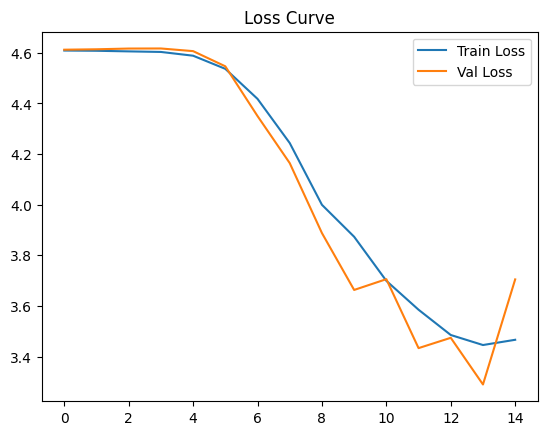

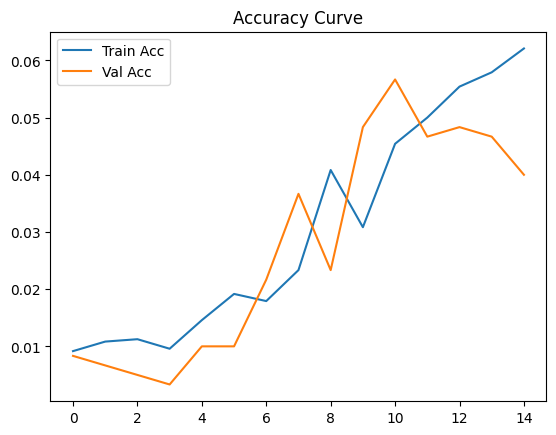

In [67]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()